# Data Science

This notebook is a place to consolidate my learning of data science techniques and a reference for when I forget things. I've tried to explain everything in my own words so when I review it, it'll make sense to me.

## Laying the foundations

For me at least, the maths is not optional.

At each stage it's important to define the specific problem being solved. Whilst each step builds on the next, it's important to remember the context for the solution as what applies at the start doesn't necessarily apply at the end.

## Univariate Linear Regression

AKA linear regression with one variable.

This is a good place to start.

A simple 2D plot with a input on the x axis and a prediction on the y axis.



In [2]:


import plotly

In [3]:
import numpy as np
# TODO: What is numpy anyway?
# Create a section on linear algebra and how it is used in numpy to calculate "things" efficiently.

# Create a section on calculus to better describe the cost function and gradient descent.
# Start by solving things algebraically, then show how this quickly breaks down and gradient descent only requires the partial derivative.

# When are things for certain a convex function and when can you not be sure?
# Things are certain when the cost function is $$1/2(y-y_hat)^
# When is it possible to know if you are in a global minimum vs a local minimum?

In [4]:
x_train = np.array([1.0, 2.0])   #(size in 1000 square feet)
y_train = np.array([300.0, 500.0])

## Regression with multiple input variables

Stop thinking about data as a table. Instead, think of a row as a vector in a matrix.

We are basically saying that any given target variable is the dot product of the input variables and some, to be calculated weights.

$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b $$

Or in the expanded form:

$$ f_{\mathbf{w},b}(\mathbf{x}) = w_1x_1 + w_2x_2 + \dots + w_nx_n + b $$

$\mathbf{x}$ is a vector or row of values from a table.


In [5]:
w = np.array([1.0, 2.5, -3.3])
b = 4
x = np.array([10, 20, 30])

In [6]:
f = w[0]*x[0] + w[1]*x[1] + w[2]*x[2] + b
f

np.float64(-35.0)

In [7]:
total = 0
for i in range(len(w)):
    total += w[i]*x[i]

total + b

np.float64(-35.0)

## Vectorization

In [8]:
f = np.dot(w, x) + b
f

np.float64(-35.0)

## What if I think my target variable scales with an x^2 term?

Polynomials are "Linear in Parameters"
Even though a polynomial like $y = w_2x^2 + w_1x + b$ in non-linear with respect to x, it is linear with respect to the coefficients $(w_2, w_1, b)$.

If each power of x is treated as a separate feature e.g. $z_1 = x, z_2 = x^2$, the equation becomes $y = w_2z + w_1x + b$.

Using ordinary least squares guarantees that you'll find the minimum value, the

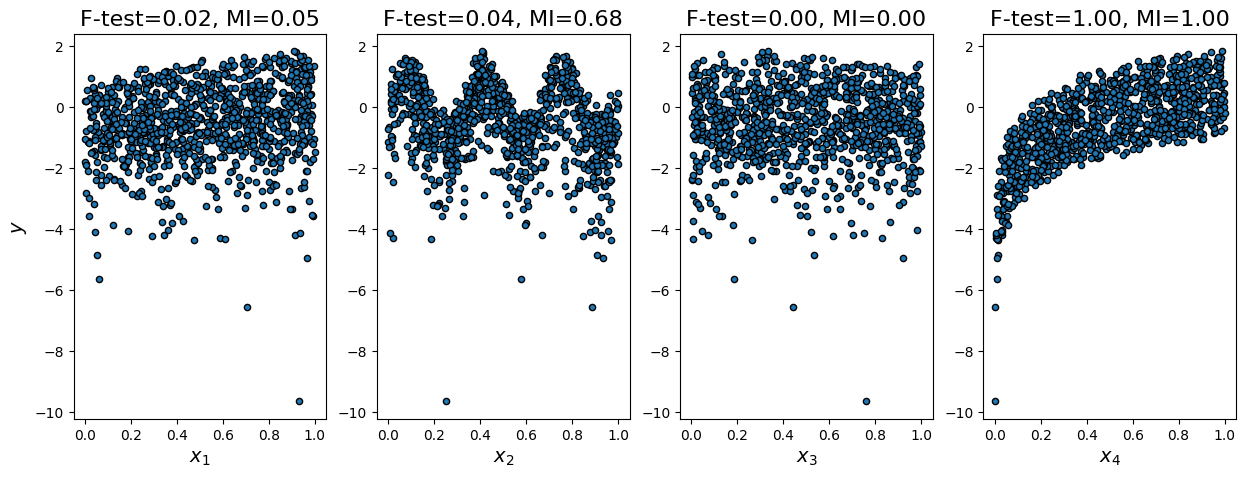

In [9]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn.feature_selection import f_regression, mutual_info_regression

np.random.seed(0)
X = np.random.rand(1000, 4)
y = X[:, 0] + np.sin(6 * np.pi * X[:, 1]) + 0.1 * np.random.randn(1000) + np.log(X[:, 3])

f_test, _ = f_regression(X, y)
f_test /= np.max(f_test)

mi = mutual_info_regression(X, y)
mi /= np.max(mi)

plt.figure(figsize=(15, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.scatter(X[:, i], y, edgecolor="black", s=20)
    plt.xlabel("$x_{}$".format(i + 1), fontsize=14)
    if i == 0:
        plt.ylabel("$y$", fontsize=14)
    plt.title("F-test={:.2f}, MI={:.2f}".format(f_test[i], mi[i]), fontsize=16)
plt.show()

In [10]:
X

array([[0.5488135 , 0.71518937, 0.60276338, 0.54488318],
       [0.4236548 , 0.64589411, 0.43758721, 0.891773  ],
       [0.96366276, 0.38344152, 0.79172504, 0.52889492],
       ...,
       [0.37634146, 0.06177907, 0.38546963, 0.24175052],
       [0.1877703 , 0.40467983, 0.11990391, 0.34963937],
       [0.43487363, 0.83000295, 0.93280618, 0.30833843]], shape=(1000, 4))

In [11]:
y

array([ 7.89664214e-01, -2.46137763e-01,  1.09923279e+00, -2.94908733e+00,
       -1.20098208e-01,  1.27774428e+00, -4.05997102e-01,  1.16720698e+00,
       -1.04330428e+00, -6.36054244e-01, -1.41467312e+00, -1.27016177e+00,
        6.99734103e-02,  7.37541375e-02, -1.79228361e+00, -8.91228663e-01,
       -1.43894867e+00,  1.05275446e+00, -3.06737130e+00, -9.52553773e-01,
        7.82999834e-01, -2.71367376e+00, -8.04460900e-01, -7.21357849e-01,
       -4.29303652e+00, -3.82503284e-01, -1.46231597e+00, -6.10539276e-01,
       -9.51603664e-01, -5.54166049e-01,  2.80683179e-01, -1.75050196e+00,
       -1.07385164e+00, -1.00092802e+00, -5.95608484e-01,  1.44330994e+00,
        1.31709548e+00,  4.82246635e-01, -8.44478140e-01, -2.72292592e+00,
        1.41278208e+00, -5.66512357e-01, -1.99598452e+00, -9.86948436e-01,
       -4.19389754e+00, -1.93487083e+00, -4.67617081e-01, -1.00822566e+00,
       -1.30818384e+00, -1.62283883e+00, -7.17002635e-01,  2.73658903e-01,
       -2.04445166e+00, -

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
linear = LinearRegression()

In [14]:
linear.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
linear.score(X, y)

0.549241887767083

In [16]:
linear.coef_

array([ 0.8112258 , -0.88592147, -0.08712616,  3.0173929 ])

In [17]:
import pandas as pd
features = pd.DataFrame(X, columns=['x_1', 'x_2', 'x_3', 'x_4'])
target = pd.DataFrame(y, columns=['y'])

In [18]:
df = pd.concat([features, target], axis=1)

In [19]:
df.to_csv('dataset.csv')

<Axes: ylabel='Frequency'>

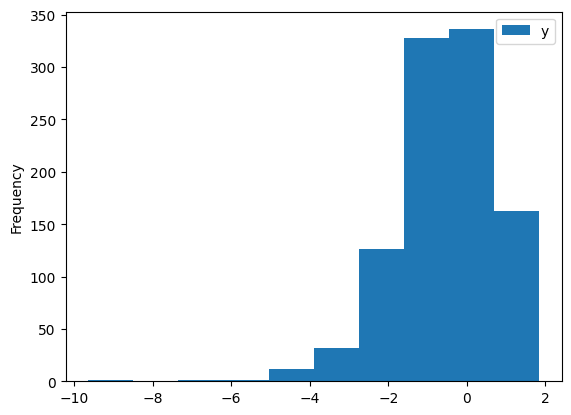

In [27]:
target.plot(kind='hist')

<Axes: xlabel='x_4', ylabel='y'>

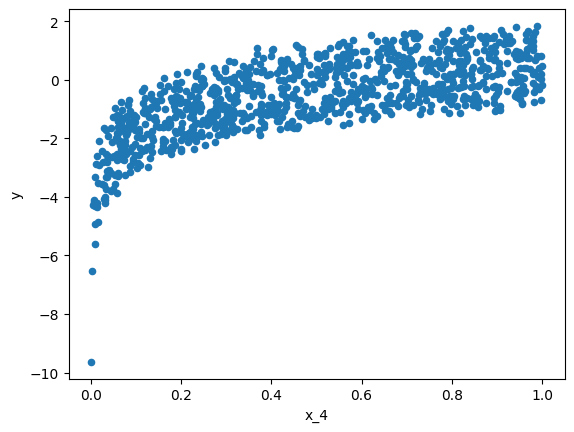

In [34]:
df.plot(x='x_4', y='y', kind='scatter')

In [38]:
df['e^y'] = np.exp(df['y'])

<Axes: xlabel='x_4', ylabel='e^y'>

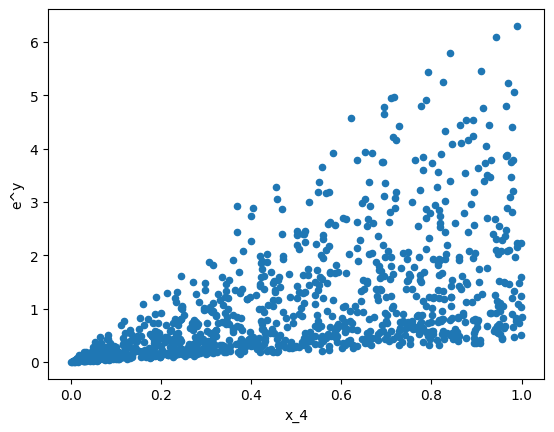

In [39]:
df.plot(x='x_4', y='e^y', kind='scatter')

In [40]:
df

,x_1,x_2,x_3,x_4,y,e^x_4,e^y
0,0.548814,0.715189,0.602763,0.544883,0.789664,1.724407,2.202657
1,0.423655,0.645894,0.437587,0.891773,-0.246138,2.439451,0.781815
2,0.963663,0.383442,0.791725,0.528895,1.099233,1.697056,3.001862
3,0.568045,0.925597,0.071036,0.087129,-2.949087,1.091038,0.052387
4,0.020218,0.832620,0.778157,0.870012,-0.120098,2.386940,0.886833
...,...,...,...,...,...,...,...
995,0.432167,0.362259,0.558138,0.076344,-1.637770,1.079334,0.194413
996,0.040346,0.511103,0.028501,0.059552,-3.178931,1.061361,0.041630
997,0.376341,0.061779,0.385470,0.241751,-0.245576,1.273476,0.782254
998,0.187770,0.404680,0.119904,0.349639,0.184542,1.418556,1.202667


array([[<Axes: title={'center': 'y'}>]], dtype=object)

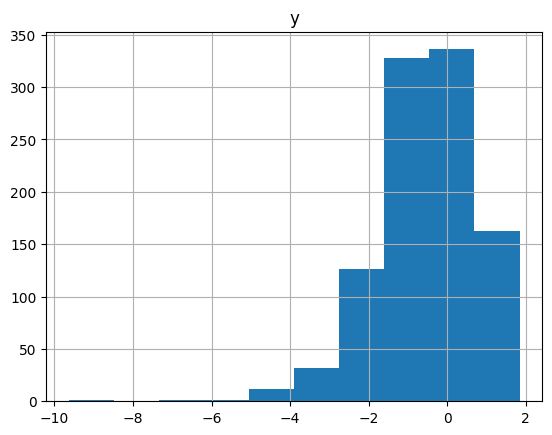